# Lab Exercise 2: Regression with the Diabetes Dataset

**Objective:** Build and evaluate linear regression models that predict the quantitative progression of diabetes one year after baseline. The first model uses only BMI; the second model uses all 10 available features.

This notebook follows the seven assignment instructions in order and uses an 80/20 train-test split with `random_state=42`.


> **Note:** This is supervised **regression** because the target is a continuous quantitative value, not a class label.


## 1. Load the Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 6)

diabetes = load_diabetes()
print("Dataset loaded successfully.")


Dataset loaded successfully.


> **Note:** `load_diabetes()` supplies labeled data: patient measurements are the input features and disease progression is the target to predict.


## 2. Explore the Data


In [2]:
diabetes_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
diabetes_df["target"] = diabetes.target

print(f"Dataset shape: {diabetes_df.shape}")
print(f"Number of samples: {diabetes.data.shape[0]}")
print(f"Number of input features: {diabetes.data.shape[1]}")
print("Feature names:", list(diabetes.feature_names))
print("\nFirst five rows:")
print(diabetes_df.head().to_string())


Dataset shape: (442, 11)
Number of samples: 442
Number of input features: 10
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

First five rows:
        age       sex       bmi        bp        s1        s2        s3        s4        s5        s6  target
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401 -0.002592  0.019907 -0.017646   151.0
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412 -0.039493 -0.068332 -0.092204    75.0
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356 -0.002592  0.002861 -0.025930   141.0
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038  0.034309  0.022688 -0.009362   206.0
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142 -0.002592 -0.031988 -0.046641   135.0


> **Note:** The DataFrame has 442 patient records, 10 input features, and 1 target column. `s1` through `s6` are six blood-serum measurements.


In [3]:
print("Data types:")
print(diabetes_df.dtypes.to_string())
print("\nMissing values:")
print(diabetes_df.isnull().sum().to_string())
print("\nDescriptive statistics:")
print(diabetes_df.describe().round(3).to_string())


Data types:
age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64

Missing values:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0

Descriptive statistics:
           age      sex      bmi       bp       s1       s2       s3       s4       s5       s6   target
count  442.000  442.000  442.000  442.000  442.000  442.000  442.000  442.000  442.000  442.000  442.000
mean    -0.000    0.000   -0.000   -0.000   -0.000    0.000   -0.000   -0.000    0.000    0.000  152.133
std      0.048    0.048    0.048    0.048    0.048    0.048    0.048    0.048    0.048    0.048   77.093
min     -0.107   -0.045   -0.090   -0.112   -0.127   -0.116   -0.102   -0.076   -0.126   -0.138   25.000
25%     -0.037   -0.045   -0.034   -0.037   -0.034   -0.030   -0.035   -0.039   -0.033   -0

> **Note:** Every column is numeric and there are no missing values, so missing-value treatment and categorical encoding are unnecessary. The input features are already standardized in the scikit-learn dataset.


## 3. Visualize BMI and the Target


Correlation between BMI and target: 0.586


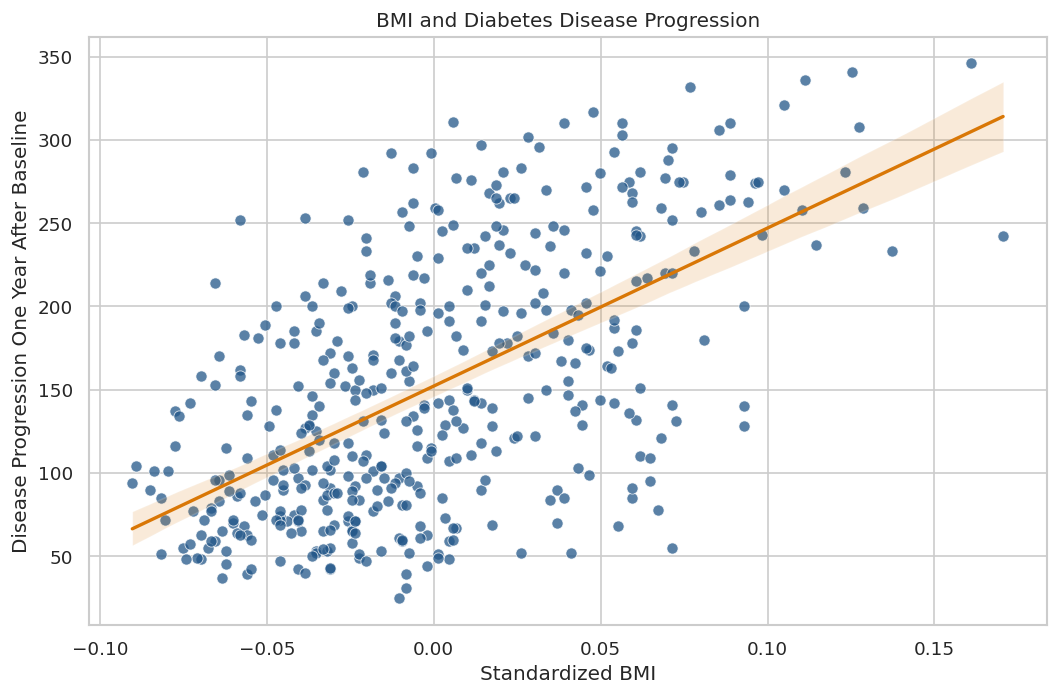

In [4]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=diabetes_df, x="bmi", y="target", color="#235789", alpha=0.75, s=45)
sns.regplot(data=diabetes_df, x="bmi", y="target", scatter=False,
            color="#D97706", line_kws={"linewidth": 2})
plt.title("BMI and Diabetes Disease Progression")
plt.xlabel("Standardized BMI")
plt.ylabel("Disease Progression One Year After Baseline")
plt.tight_layout()
plt.show()

bmi_target_correlation = diabetes_df["bmi"].corr(diabetes_df["target"])
print(f"Correlation between BMI and target: {bmi_target_correlation:.3f}")


> **Note:** The scatter plot and correlation of **0.586** show a moderate positive relationship. Higher standardized BMI generally corresponds to greater disease progression, but the wide spread means BMI alone cannot explain all target variation.


## 4. Prepare the BMI-Only Data


In [5]:
X_bmi = diabetes_df[["bmi"]]
y = diabetes_df["target"]

X_bmi_train, X_bmi_test, y_bmi_train, y_bmi_test = train_test_split(
    X_bmi, y, test_size=0.20, random_state=42
)
print(f"BMI training set: {X_bmi_train.shape[0]} samples")
print(f"BMI testing set: {X_bmi_test.shape[0]} samples")


BMI training set: 353 samples
BMI testing set: 89 samples


> **Note:** The split creates **353 training records** and **89 testing records**. `random_state=42` makes the split reproducible, while the untouched test set represents unseen data.


## 5. Train the BMI-Only Linear Regression Model


In [6]:
bmi_model = LinearRegression()
bmi_model.fit(X_bmi_train, y_bmi_train)
print("BMI-only model trained successfully.")
print(f"Intercept: {bmi_model.intercept_:.3f}")
print(f"BMI coefficient: {bmi_model.coef_[0]:.3f}")


BMI-only model trained successfully.
Intercept: 152.003
BMI coefficient: 998.578


> **Note:** The model learned an intercept of **152.003** and a positive BMI coefficient of **998.578**. Because BMI is standardized, the coefficient describes the prediction change for a one-unit increase in standardized BMI.


## 6. Evaluate the BMI-Only Model


In [7]:
y_bmi_pred = bmi_model.predict(X_bmi_test)
bmi_mse = mean_squared_error(y_bmi_test, y_bmi_pred)
bmi_r2 = r2_score(y_bmi_test, y_bmi_pred)
print(f"BMI-only Mean Squared Error (MSE): {bmi_mse:.2f}")
print(f"BMI-only R-squared (R²): {bmi_r2:.4f}")


BMI-only Mean Squared Error (MSE): 4061.83
BMI-only R-squared (R²): 0.2334


> **Note:** The BMI-only model has **MSE = 4061.83** and **R² = 0.2334**. It explains about **23.34%** of the variation in the unseen test targets, leaving substantial unexplained variation. Lower MSE and higher R² indicate better performance.


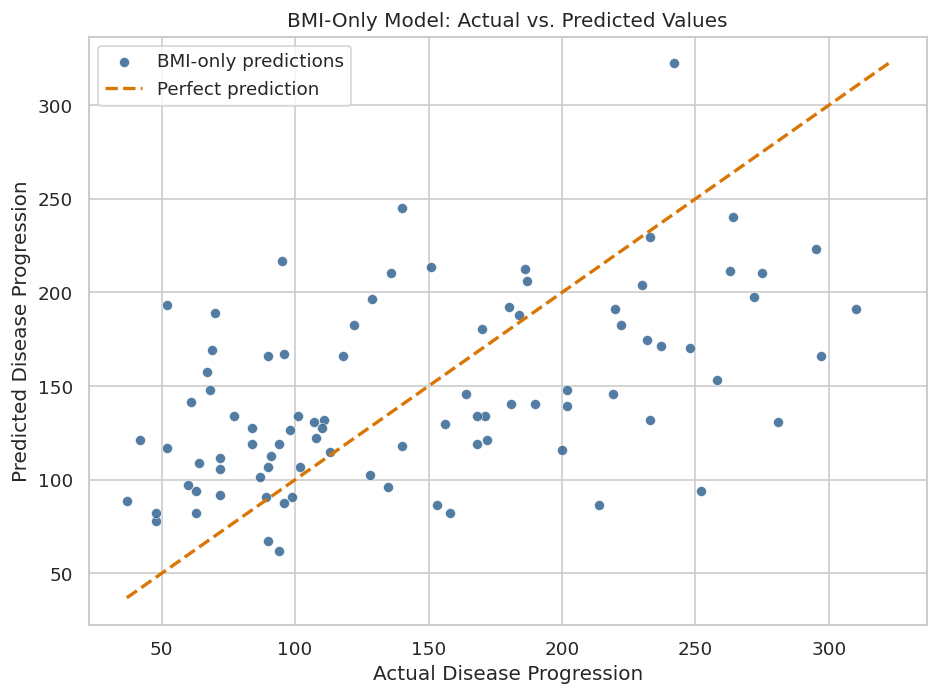

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_bmi_test, y_bmi_pred, color="#235789", alpha=0.78,
            edgecolor="white", linewidth=0.4, label="BMI-only predictions")
low = min(y_bmi_test.min(), y_bmi_pred.min())
high = max(y_bmi_test.max(), y_bmi_pred.max())
plt.plot([low, high], [low, high], color="#D97706", linewidth=2,
         linestyle="--", label="Perfect prediction")
plt.title("BMI-Only Model: Actual vs. Predicted Values")
plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")
plt.legend()
plt.tight_layout()
plt.show()


> **Note:** Points on the dashed diagonal would be exact predictions. Their spread away from the line confirms that BMI captures part of the pattern but produces sizable errors for many patients.


## 7. Repeat the Model Using All Features


In [9]:
X_all = diabetes_df[diabetes.feature_names]
X_all_train, X_all_test, y_all_train, y_all_test = train_test_split(
    X_all, y, test_size=0.20, random_state=42
)
all_features_model = LinearRegression()
all_features_model.fit(X_all_train, y_all_train)
y_all_pred = all_features_model.predict(X_all_test)
all_features_mse = mean_squared_error(y_all_test, y_all_pred)
all_features_r2 = r2_score(y_all_test, y_all_pred)

print(f"All-features training set: {X_all_train.shape}")
print(f"All-features testing set: {X_all_test.shape}")
print(f"All-features Mean Squared Error (MSE): {all_features_mse:.2f}")
print(f"All-features R-squared (R²): {all_features_r2:.4f}")


All-features training set: (353, 10)
All-features testing set: (89, 10)
All-features Mean Squared Error (MSE): 2900.19
All-features R-squared (R²): 0.4526


> **Note:** With all 10 features, test performance improves to **MSE = 2900.19** and **R² = 0.4526**. The model explains about **45.26%** of test-target variation. The same split makes this a fair comparison with the BMI-only model.


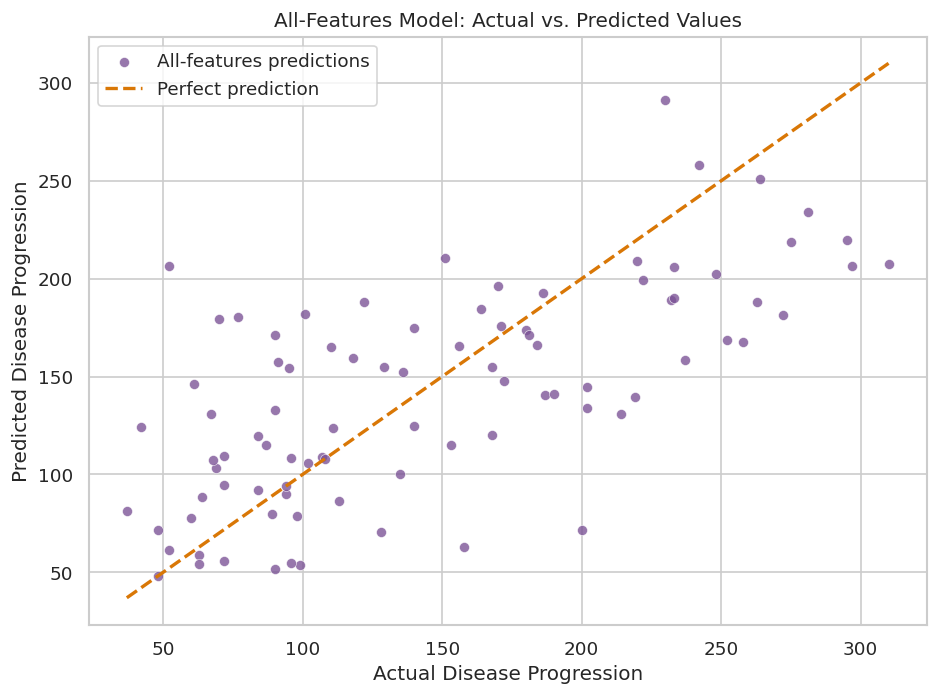

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(y_all_test, y_all_pred, color="#7A5195", alpha=0.78,
            edgecolor="white", linewidth=0.4, label="All-features predictions")
low = min(y_all_test.min(), y_all_pred.min())
high = max(y_all_test.max(), y_all_pred.max())
plt.plot([low, high], [low, high], color="#D97706", linewidth=2,
         linestyle="--", label="Perfect prediction")
plt.title("All-Features Model: Actual vs. Predicted Values")
plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")
plt.legend()
plt.tight_layout()
plt.show()


> **Note:** The all-features predictions generally sit closer to the perfect-prediction line than the BMI-only predictions, which agrees with the improved MSE and R² scores.


## 8. Performance Comparison


In [11]:
comparison = pd.DataFrame({
    "Model": ["BMI only", "All 10 features"],
    "MSE": [bmi_mse, all_features_mse],
    "R²": [bmi_r2, all_features_r2]
})
comparison["MSE reduction vs. BMI"] = [0.0, bmi_mse - all_features_mse]
comparison["R² increase vs. BMI"] = [0.0, all_features_r2 - bmi_r2]
print(comparison.round(4).to_string(index=False))


          Model       MSE     R²  MSE reduction vs. BMI  R² increase vs. BMI
       BMI only 4061.8259 0.2334                 0.0000               0.0000
All 10 features 2900.1936 0.4526              1161.6323               0.2193


> **Note:** Adding all features reduces MSE by **1161.63** (about **28.60%**) and increases R² by **0.2193**. Therefore, the all-features model performs better on the unseen test set.


## Conclusion


BMI has a meaningful positive relationship with diabetes disease progression, but it does not contain enough information to predict the outcome accurately by itself. Using all 10 physiological features lowers prediction error and explains a larger share of the target variation. Therefore, the all-features linear regression model is the stronger of the two models tested.


> **Note:** These results describe predictive performance for this dataset and the specified 80/20 split. They do not prove that any feature causes diabetes progression.
